Our company is considering investing in the video game industry, but we are trying to determine the appropriate area. You have been tasked to evaluate the performance of the video game industry. Using the Video Game data set, you are to develop a presentation that shows answers to the following questions:

1. What is the top video game by units?
    1. Data is in Millions of units.
    2. You should show the Game title and units.
2. What is the top video game by the number of users?
    1. Ensure results are rounded to the nearest whole number.
    2. You should show the Game Title and the number of users.
3. What are the 10 most successful games in North America by units?
    1. This is to be plotted in a bar chart.
        1. Display the Game Title on the 'X' axis.
        2. Display the units on the 'Y' axis.
4. Show the 10 most successful games in North America by units for games released after 2010.
    1. This is to be plotted in a bar chart.
        1. Display the Game Title on the 'X' axis.
        2. Display the units on the 'Y' axis.
        3. Display only the horizontal grid lines for units.
5. What is the total units for all games over the years represented in the data?
    1. This is to be plotted in a line chart.

Your presentation should culminate in your recommendation for where our company should invest within this industry. You should provide a narrative with a convincing argument supported by your data analysis.

  

**Required Canvas submissions:**

- Submit a single Jupyter notebook of your analysis titled _'yourname_Project1_'_
- Submit a PowerPoint presentation of your analysis and conclusion.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('http://128.198.162.191/dataFiles/VIDEO-GAMES/Video_Games.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  str    
 1   Platform         16719 non-null  str    
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  str    
 4   Publisher        16665 non-null  str    
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  str    
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  str    
 15  Rating           9950 non-null   str    
dtypes: float64(9), str(7)
memory usage: 2.0 MB


In [5]:
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


# What is the top video game by units?
Given that there isn't any specific requirement for combining game across platforms in this question, this is performed by a simple sort.

In [6]:
bestGames = df.sort_values(by='Global_Sales', ascending=False)

topGame = bestGames.head(1)

topFinal = topGame[['Name', 'Global_Sales']]

print('Top selling game:')
print(topFinal)

Top selling game:
         Name  Global_Sales
0  Wii Sports         82.53


## You can group the video games by the Name to combine the sales across all platforms, but you'll receive the same results.

In [7]:
GameName = df.groupby('Name')['Global_Sales'].sum().sort_values(ascending=False)

GameName.head(5)

Name
Wii Sports            82.53
Grand Theft Auto V    56.57
Super Mario Bros.     45.31
Tetris                35.84
Mario Kart Wii        35.52
Name: Global_Sales, dtype: float64

# What is the top video game by number of users?

Similar to the above question, the simplicity of the question allows us to perform a similar sort, just using different columns.

In [8]:
bestUsers = df.sort_values(by='User_Count', ascending=False)

topUser = bestUsers.head(1)

userFinal = topUser[['Name', 'User_Count']]

print('Top game by User count: ')
print(userFinal)

Top game by User count: 
                          Name  User_Count
2851  The Witcher 3: Wild Hunt     10665.0


## Again you can group by game name, but will get the same results.

In [9]:
GameName = df.groupby('Name')['User_Count'].sum().sort_values(ascending=False)

GameName.head(5)

Name
The Witcher 3: Wild Hunt          24807.0
Call of Duty: Modern Warfare 3    20053.0
The Elder Scrolls V: Skyrim       15189.0
Grand Theft Auto V                15124.0
Fallout 4                         13489.0
Name: User_Count, dtype: float64

# Ten most successful games in North America by units sold?
This question now requires us to not only perform a sort but to limit the number of records returned. After which we can then plot the results into a visualization.

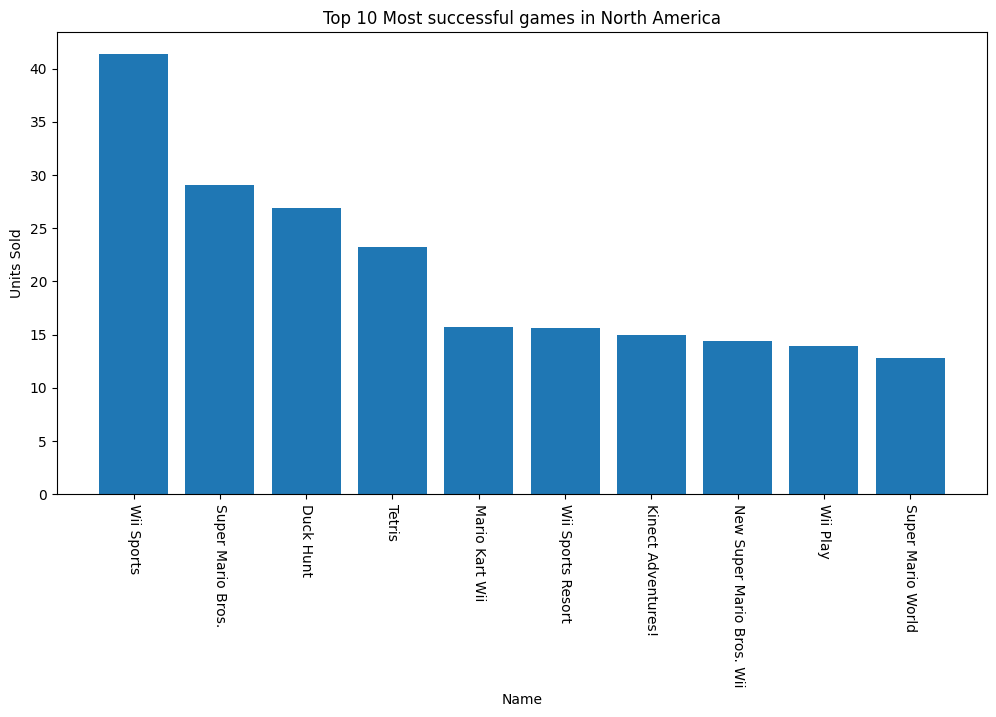

In [ ]:
bestGame = df.sort_values(by='NA_Sales', ascending=False)

bestGame.head(10)

topTen = bestGame.head(10)

# Visualize the results.
plt.figure(figsize=(12,6))

# Fields used to display the chart
plt.bar(topTen['Name'], topTen['NA_Sales'])

plt.title('Top 10 Most successful games in North America')
plt.xlabel('Name')
plt.ylabel('Units Sold')
plt.xticks(rotation=270)
plt.show()

# Show the ten most successful games in North America by units sold released after 2010.
This question requires not only the sorting we've used so far but also a query to find release date, and a limitation of the number of records returned. Once we've done that we can visualize the results.

In [34]:
after2010 = (df.query('Year_of_Release > 2010'))

topGamesGroup = after2010.groupby('Name')['NA_Sales'].sum().sort_values(ascending=False)

topGamesGroup.head(10)

graphOutput = topGamesGroup.head(10)

graphOutput

Name
Grand Theft Auto V                23.84
Call of Duty: Modern Warfare 3    15.54
Call of Duty: Ghosts              14.94
Call of Duty: Black Ops II        14.08
Call of Duty: Black Ops 3         12.25
Minecraft                         11.28
Call of Duty: Advanced Warfare    10.51
The Elder Scrolls V: Skyrim        9.65
Battlefield 3                      8.20
Just Dance 3                       7.75
Name: NA_Sales, dtype: float64

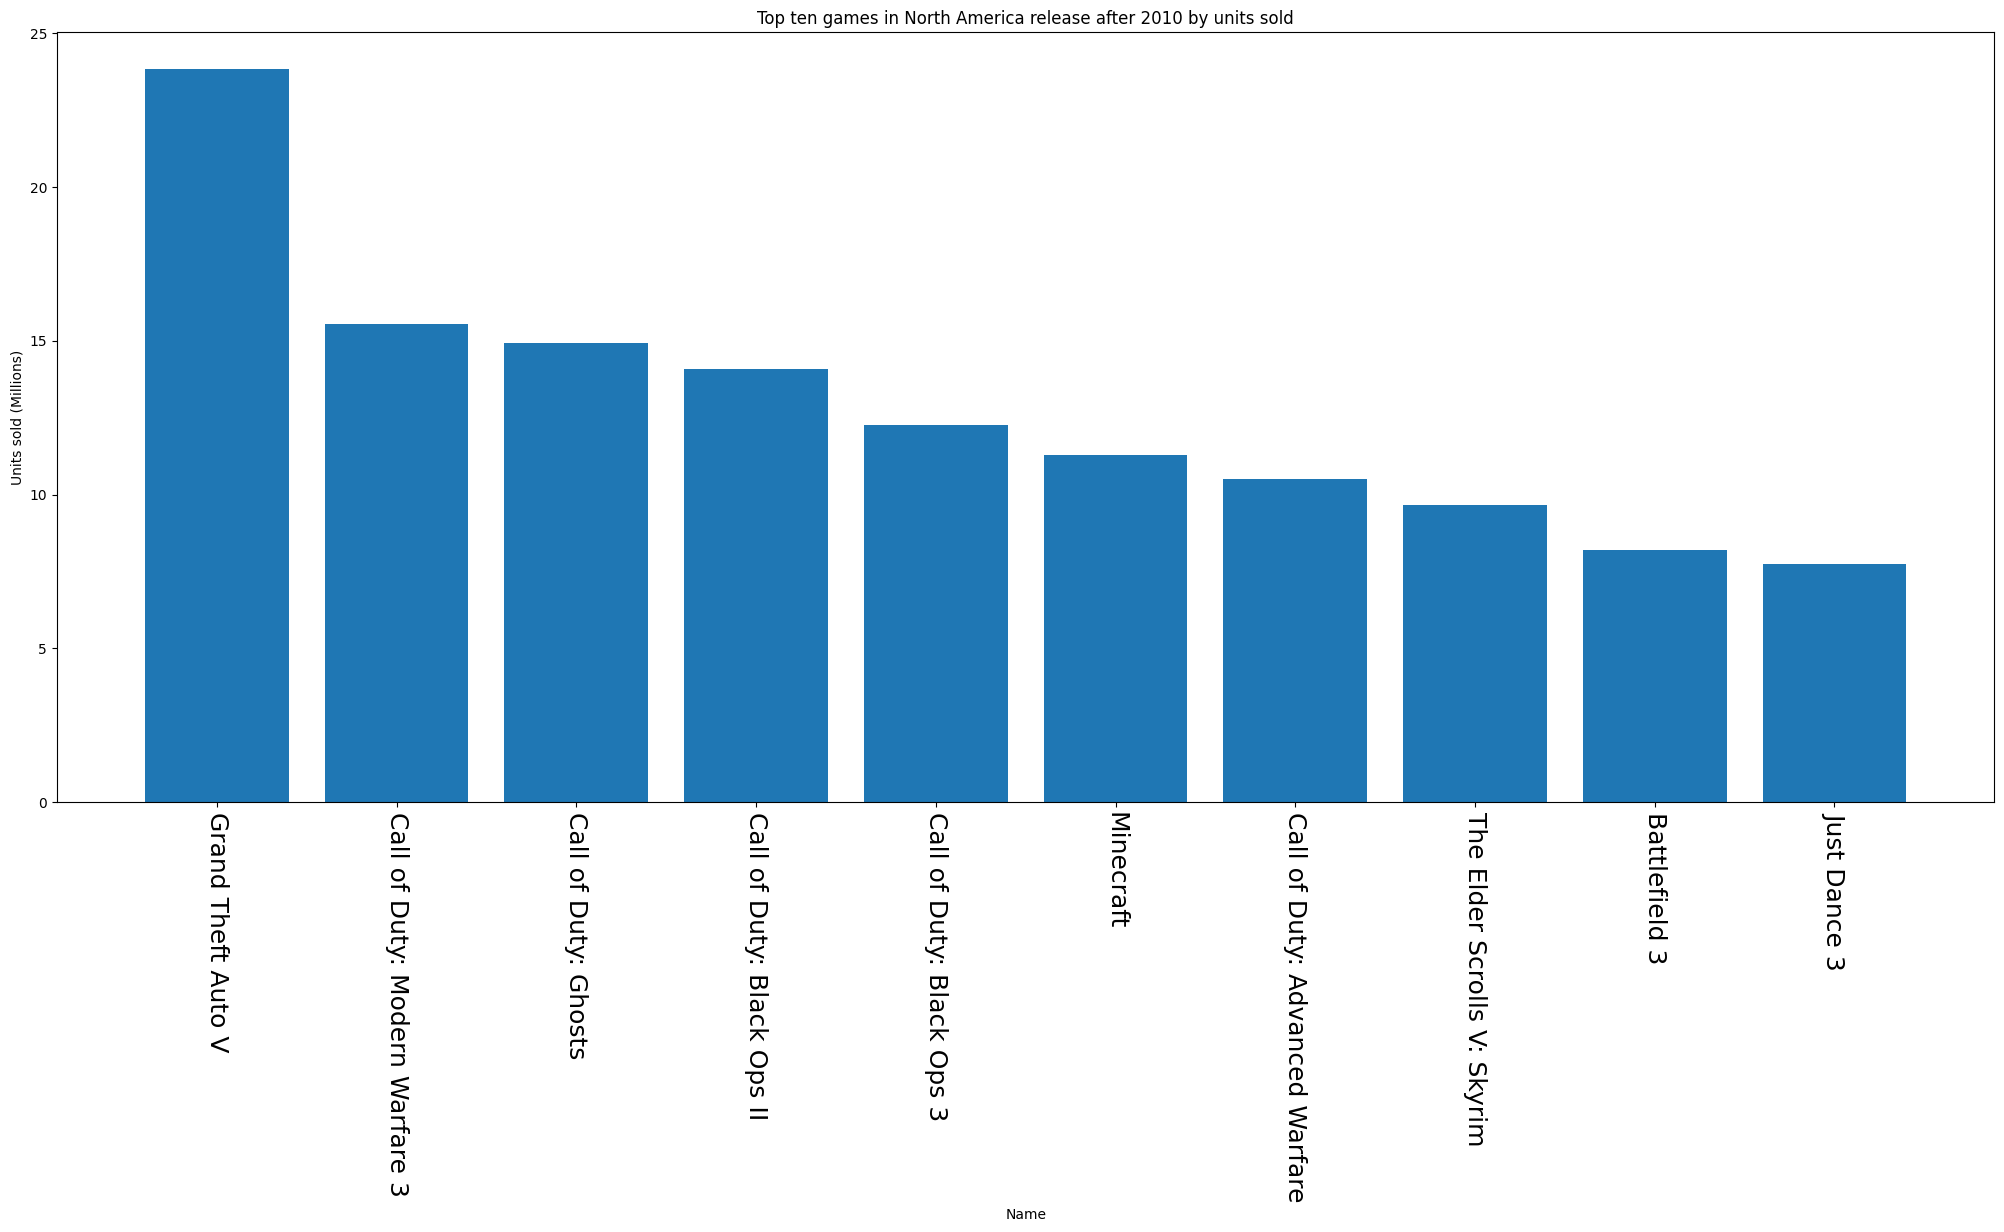

In [38]:
# Visualize the results.
plt.figure(figsize=(25,10))

plt.bar(graphOutput.index.get_level_values('Name'), graphOutput.values)

plt.title('Top ten games in North America release after 2010 by units sold')
plt.xlabel('Name')
plt.xticks(rotation=270, fontsize=18)
plt.ylabel('Units sold (Millions)')
plt.show()

# What is the total units sold for all games over the years represented in the data?
This question requires a simple grouping of the data by 'Year_of_Release', and 'Global_Sales'.

In [13]:
totalUnitsByYear = df.groupby('Year_of_Release')['Global_Sales'].sum()

print(totalUnitsByYear)

Year_of_Release
1980.0     11.38
1981.0     35.77
1982.0     28.86
1983.0     16.79
1984.0     50.36
1985.0     53.94
1986.0     37.07
1987.0     21.74
1988.0     47.22
1989.0     73.45
1990.0     49.39
1991.0     32.23
1992.0     76.17
1993.0     48.40
1994.0     79.18
1995.0     88.11
1996.0    199.15
1997.0    200.98
1998.0    256.45
1999.0    251.25
2000.0    201.58
2001.0    331.47
2002.0    395.51
2003.0    357.80
2004.0    419.05
2005.0    458.31
2006.0    518.22
2007.0    605.37
2008.0    671.79
2009.0    658.88
2010.0    590.59
2011.0    507.79
2012.0    355.84
2013.0    361.24
2014.0    331.51
2015.0    268.05
2016.0    130.10
2017.0      0.06
2020.0      0.29
Name: Global_Sales, dtype: float64


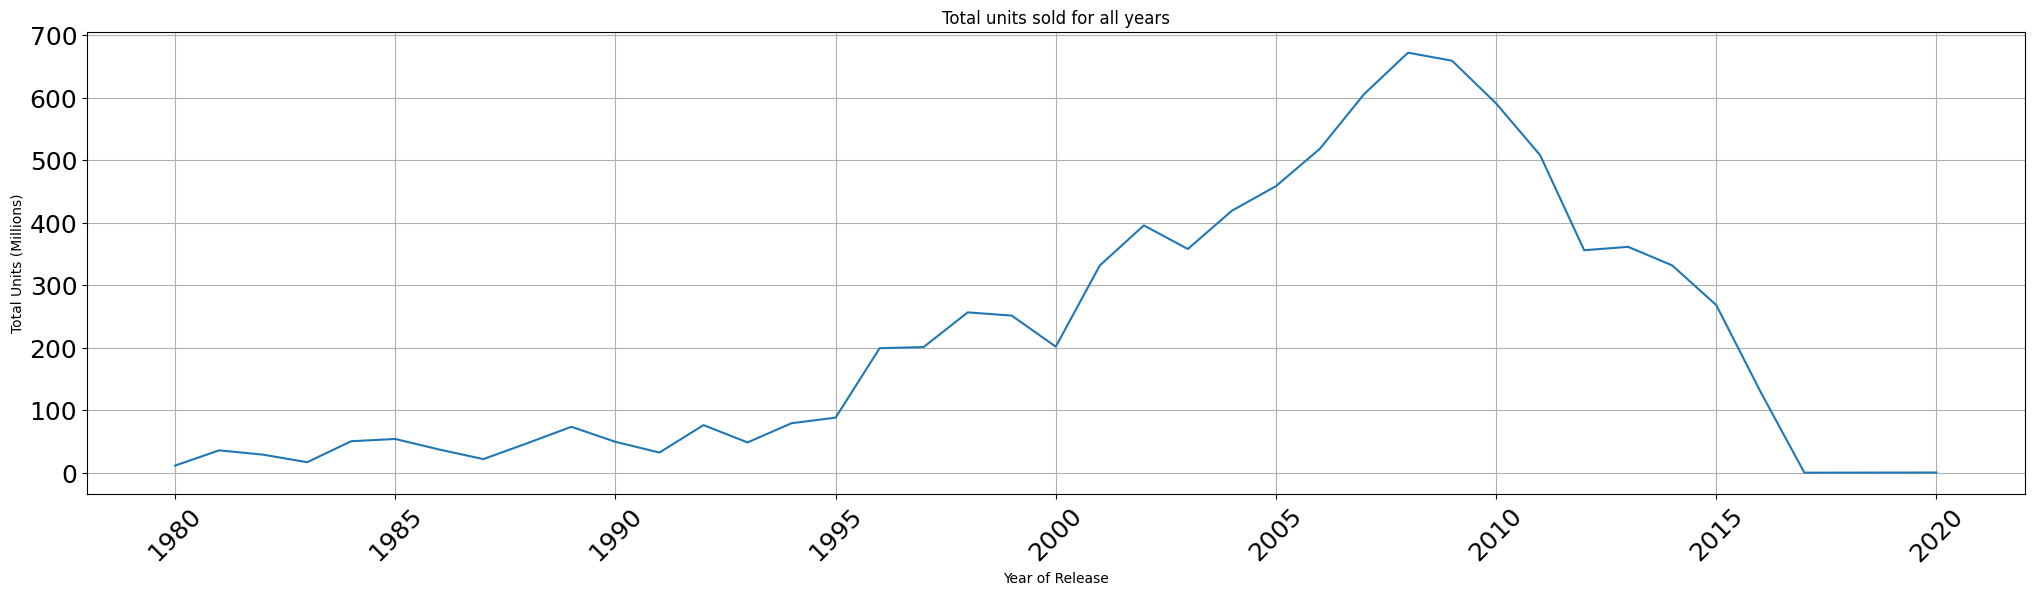

In [14]:
plt.figure(figsize=(25,6))

plt.plot(totalUnitsByYear.index, totalUnitsByYear.values)

plt.xlabel('Year of Release')
plt.xticks(rotation=45, fontsize=18)
plt.ylabel('Total Units (Millions)')
plt.yticks(fontsize=18)
plt.title('Total units sold for all years')
plt.grid()
plt.show()